<a href="https://colab.research.google.com/github/farrelrassya/time-series-forecasting-in-python/blob/main/Chapter_02_A_Naive_Prediction_of_the_Future.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2: A Naive Prediction of the Future

*Time Series Forecasting in Python* -- Marco Peixeiro (Manning, 2022)

---

**Chapter overview.** Chapter 1 told us *what* a time series is and *why* forecasting it differs from ordinary regression. This chapter is the first one where we actually predict the future.

We will not yet reach for any sophisticated model -- no ARIMA, no LSTM, no exogenous regressors. Instead, we build **four naive baselines** for the Johnson & Johnson quarterly earnings-per-share (EPS) data from chapter 1, evaluate each one on a held-out test set, and use the comparison to learn something concrete about the data's structure.

The four baselines are:

1. The **historical mean** -- predict the average of the entire training set.
2. The **last year's mean** -- predict the average of the most recent four quarters.
3. The **last known value** -- predict the most recent observation.
4. The **naive seasonal forecast** -- repeat the last full seasonal cycle.

Each baseline is a one-line implementation. None requires fitting in the statistical sense. And yet, by comparing their out-of-sample errors, we will discover that:

- An average over the full $20$ years badly under-predicts a series with a trend.
- An average over the last year is a large improvement.
- The last single observation is worse than the last-year mean because it ignores within-year seasonality.
- Repeating the last seasonal cycle is the best of the four -- which already tells us that seasonality is a dominant feature of this data, before we have run a single statistical test.

**Why baselines matter.** A baseline is a contract with future modeling work: any sophisticated model must beat the best naive baseline, or it has not earned its complexity. We will carry the **mean absolute percentage error (MAPE) of $11.56\%$** from the naive seasonal baseline as the benchmark to beat in every subsequent chapter.

---

### What is a baseline model?

> A baseline model is a trivial solution to your forecasting problem. It relies on heuristics or simple statistics and is usually the simplest solution. It does not require model fitting, and it is easy to implement.

In time series we have a particularly natural baseline: a single arithmetic statistic of the past. We compute it once, use it for every future timestep, and measure how badly we do.


## 2.1 Setup

We use the same J&J quarterly EPS dataset from chapter 1: $84$ observations spanning $1960$-$1980$. The plan:

- Treat the first $80$ rows ($1960$-$1979$) as the **training set**.
- Treat the last $4$ rows (the four quarters of $1980$) as the **test set**.
- Build each baseline from the training data alone.
- Compare each baseline's predictions for $1980$ against the actual $1980$ values using **MAPE**.

This is **out-of-sample** evaluation: the model never sees the test data during construction, so the error we measure is a faithful estimate of how the baseline would perform on truly unseen future data.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# Avoid the SettingWithCopyWarning when assigning prediction columns to test
pd.options.mode.chained_assignment = None

url = 'https://raw.githubusercontent.com/marcopeix/TimeSeriesForecastingInPython/master/data/jj.csv'
df = pd.read_csv(url)

print("First five rows:")
print(df.head().to_string(index=True))
print("\nLast five rows:")
print(df.tail().to_string(index=True))
print(f"\nShape: {df.shape}")


First five rows:
         date  data
0  1960-01-01  0.71
1  1960-04-01  0.63
2  1960-07-02  0.85
3  1960-10-01  0.44
4  1961-01-01  0.61

Last five rows:
          date   data
79  1979-10-01   9.99
80  1980-01-01  16.20
81  1980-04-01  14.67
82  1980-07-02  16.02
83  1980-10-01  11.61

Shape: (84, 2)


The DataFrame has two columns -- `date` (the end of each quarter) and `data` (the EPS in USD) -- and $84$ rows. The head shows the same 1960-Q1 through 1961-Q1 values we worked with in chapter 1. The tail shows the four quarters of 1980 (rows 80-83), which will be our **test set**, plus 1979-Q4 (\$9.99), the last row of what will be our **training set**.

The 1980 values we must predict are \$16.20, \$14.67, \$16.02, \$11.61 -- continuing both the upward trend and the strong Q4 dip pattern we identified in chapter 1.

Now let us visualize the train/test split, with the forecast horizon shaded.


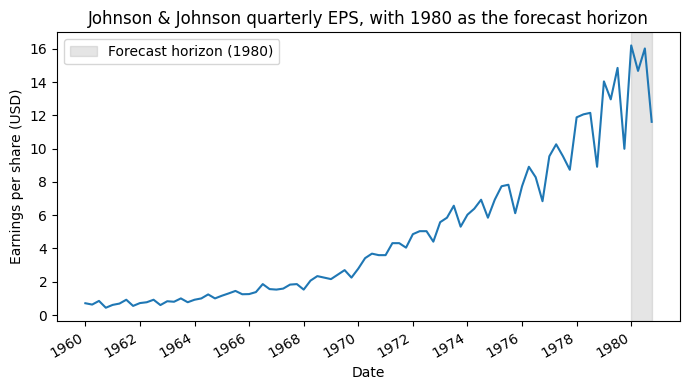

In [2]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(df['date'], df['data'])
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.set_title('Johnson & Johnson quarterly EPS, with 1980 as the forecast horizon')
ax.axvspan(80, 83, color='#808080', alpha=0.2, label='Forecast horizon (1980)')
ax.legend(loc='upper left')

plt.xticks(np.arange(0, 81, 8),
           [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**Figure 2.1** reproduces the book's setup figure. The full series is plotted; the gray band on the right marks the four quarters of $1980$, the period we will forecast. Notice that this is exactly the regime where the trend is steepest -- the values we need to predict (the four 1980 points) range from \$11.61 to \$16.20, while a simple average over $1960$-$1979$ would land near \$4. Any baseline that does not adapt to the trend is going to badly under-predict here.

Let us do the train/test split now.


In [3]:
train = df[:-4]
test = df[-4:]

print(f"Training set: {len(train)} rows, dates {train['date'].iloc[0]} to {train['date'].iloc[-1]}")
print(f"Test set:     {len(test)} rows, dates {test['date'].iloc[0]} to {test['date'].iloc[-1]}")


Training set: 80 rows, dates 1960-01-01 to 1979-10-01
Test set:     4 rows, dates 1980-01-01 to 1980-10-01


The split gives us $80$ training observations (Q1-1960 through Q4-1979) and $4$ test observations (the four quarters of 1980). The training set is what every baseline below sees; the test set is held out for scoring only.

**A note on time series train/test splits.** Unlike the random K-fold split used in ordinary regression, time series splits **must respect order**. The test set is always the most recent block of observations; the training set is everything before. Random shuffling would let the model "peek into the future" and inflate test scores artificially -- the look-ahead bias problem we flagged in chapter 1.


## 2.2 The MAPE error metric

We need a single number to compare baselines. The book uses **mean absolute percentage error (MAPE)**:

$$\text{MAPE} = \frac{100}{n} \sum_{i=1}^{n} \left| \frac{A_i - F_i}{A_i} \right|$$

where $A_i$ is the actual value at time $i$, $F_i$ is the forecast at time $i$, and $n$ is the number of forecasts (here $n = 4$).

**Why this metric and not MSE or MAE?**

- **Scale-independent.** A MAPE of $15\%$ means the same thing whether the EPS is in dollars or pesos, whether the values are in single digits or millions. This makes it easy to communicate to non-technical stakeholders.
- **Interpretable.** A MAPE of $11.56\%$ literally says "on average, our forecast is off by $11.56\%$ of the actual value." MSE in dollars-squared is harder to interpret.
- **Symmetric in absolute terms** between over- and under-prediction (though it does penalize them slightly differently in relative terms -- a quirk we won't dwell on here).

**MAPE has weaknesses too**: it blows up when $A_i$ is near zero, and it penalizes under-prediction less than over-prediction (because the denominator is bigger when you under-predict). For J&J EPS those weaknesses don't bite, so MAPE is a fine choice.

Implementation is one line:


In [4]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Quick sanity check: if forecast equals actual, MAPE should be 0
y = np.array([10.0, 20.0, 30.0, 40.0])
print(f"MAPE(y, y) = {mape(y, y):.4f}%   (expected 0)")
# If forecast is always 10% above actual, MAPE should be 10%
print(f"MAPE(y, 1.1*y) = {mape(y, 1.1*y):.4f}%   (expected 10)")


MAPE(y, y) = 0.0000%   (expected 0)
MAPE(y, 1.1*y) = 10.0000%   (expected 10)


The function returns $0.0\%$ when prediction matches actual exactly, and $10.0\%$ when the prediction is uniformly $10\%$ too high -- both as expected.

The implementation is vectorized: numpy broadcasts the subtraction, division, and absolute value across the four-element arrays, then `np.mean` averages and we multiply by $100$ to turn a decimal into a percentage. No loop required.


## 2.3 Baseline 1: The historical mean

**The model.** Predict the same value for every quarter of 1980: the arithmetic mean of all training-set values.

$$\hat y_t = \bar y_{\text{train}} = \frac{1}{n_{\text{train}}} \sum_{i=1}^{n_{\text{train}}} y_i$$

In code:


In [5]:
historical_mean = np.mean(train['data'])
print(f"Historical mean (1960-Q1 through 1979-Q4): ${historical_mean:.4f}")


Historical mean (1960-Q1 through 1979-Q4): $4.3085


The mean of the $80$ training observations is **\$4.3085**. This is the forecast for all four 1980 quarters under this baseline.

To see why this is a poor forecast, recall the structure we identified in chapter 1: the J&J series grew from \$0.71 to \$9.99 over the training period, a $15\%$ annual compounded growth rate, and is *still* growing into 1980. The full-history mean (\$4.31) is essentially a midpoint of the trend -- representative of $1970$, not of $1979$ or $1980$. Using it as a 1980 forecast guarantees a large under-prediction.

Let us attach this prediction to the test DataFrame, score it, and visualize the result.


In [6]:
test.loc[:, 'pred_mean'] = historical_mean
print(test.to_string(index=True))

mape_hist_mean = mape(test['data'].values, test['pred_mean'].values)
print(f"\nMAPE of historical-mean baseline: {mape_hist_mean:.2f}%")


          date   data  pred_mean
80  1980-01-01  16.20     4.3085
81  1980-04-01  14.67     4.3085
82  1980-07-02  16.02     4.3085
83  1980-10-01  11.61     4.3085

MAPE of historical-mean baseline: 70.01%


The test DataFrame now carries the actual 1980 values alongside the constant \$4.3085 prediction. The MAPE is **$70.01\%$** -- forecasts deviate from the actual EPS by $70\%$ on average. We can do the per-quarter arithmetic in our heads to confirm: $|16.20 - 4.31|/16.20 \approx 73\%$ for Q1, $|14.67 - 4.31|/14.67 \approx 71\%$ for Q2, and so on. Averaging the four percentages gives the reported $70.01\%$.

Visually:


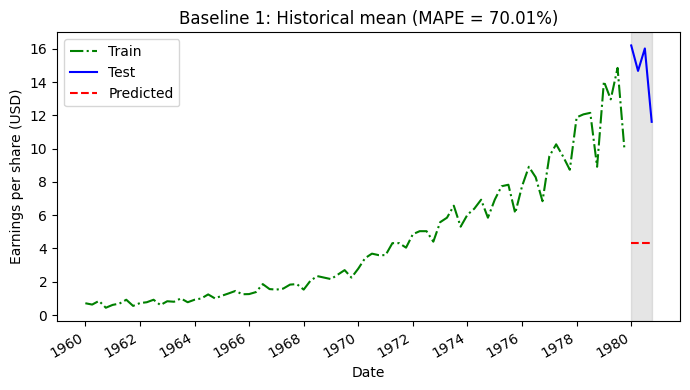

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(train['date'], train['data'], 'g-.', label='Train')
ax.plot(test['date'], test['data'], 'b-', label='Test')
ax.plot(test['date'], test['pred_mean'], 'r--', label='Predicted')
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.set_title('Baseline 1: Historical mean (MAPE = 70.01%)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)
ax.legend(loc='upper left')

plt.xticks(np.arange(0, 85, 8),
           [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**Figure 2.2** shows the green training data climbing through the 1970s, the blue test data continuing the climb into 1980, and the red prediction line stuck flat at \$4.31. The gap is enormous -- the prediction line sits roughly $10$ dollars below the test line for every quarter.

**Lesson learned.** A flat baseline computed from all-time history is useless for a series with a strong trend. The mean is dominated by the small early values (the $1960$s were sub-\$1.00 EPS), which have nothing to say about the EPS regime of the late $1970$s and beyond.

Two fixes suggest themselves: either use only the *recent* past (next baseline), or use a model that explicitly captures the trend (deferred to chapter 6+). We try the recency fix first because it is essentially free.


## 2.4 Baseline 2: Last year's mean

**The model.** Predict the same value for every quarter of 1980: the arithmetic mean of *only* the most recent four training observations (i.e., the four quarters of 1979).

$$\hat y_t = \bar y_{1979} = \frac{1}{4}\sum_{i=n_{\text{train}}-3}^{n_{\text{train}}} y_i$$

The hypothesis being tested is that **recent values are more representative of the near future than distant values are**. For a trending series this should be a much better prediction than the full-history mean.


In [8]:
last_year_mean = np.mean(train['data'][-4:])
print(f"Mean of 1979 (last four training observations): ${last_year_mean:.4f}")
print(f"Compare to historical mean: ${historical_mean:.4f}")
print(f"Difference: ${last_year_mean - historical_mean:.4f}")


Mean of 1979 (last four training observations): $12.9600
Compare to historical mean: $4.3085
Difference: $8.6515


The 1979 mean is **\$12.96** -- exactly three times the full-history mean (\$4.31). The arithmetic is intuitive: $1979$ EPS values are $\$14.04$, $\$12.96$, $\$14.85$, $\$9.99$, averaging to $\$12.96$. This is much closer to the 1980 regime (which we will eventually see averages \$14.63) but still systematically under-predicts because the trend continued growing into 1980.

Score and visualize it:


In [9]:
test.loc[:, 'pred_last_yr_mean'] = last_year_mean

mape_last_year_mean = mape(test['data'].values, test['pred_last_yr_mean'].values)
print(f"MAPE of last-year-mean baseline: {mape_last_year_mean:.2f}%")
print(f"\nImprovement over historical mean: {mape_hist_mean - mape_last_year_mean:.2f} percentage points")
print(f"Relative improvement: {(mape_hist_mean - mape_last_year_mean)/mape_hist_mean*100:.1f}%")


MAPE of last-year-mean baseline: 15.60%

Improvement over historical mean: 54.41 percentage points
Relative improvement: 77.7%


The MAPE drops from $70.01\%$ to **$15.60\%$** -- a $54.4$ percentage point improvement, or a $77.7\%$ relative reduction in error. Using only the last year of data instead of all twenty years has transformed a useless baseline into a quite reasonable one. The cost: zero -- it is the same one-line computation, just on a four-element slice.

**Why such a large improvement?** Because the trend signal dominates this series ($99.1\%$ of the variance, per chapter 1's decomposition). Throwing out the old (small) values brings the prediction much closer to the right *level*. What it still cannot do is capture the *within-year* seasonal pattern: the flat \$12.96 prediction will under-shoot the Q1, Q2, Q3 surpluses and over-shoot the Q4 trough.

Plot it next to the previous attempt:


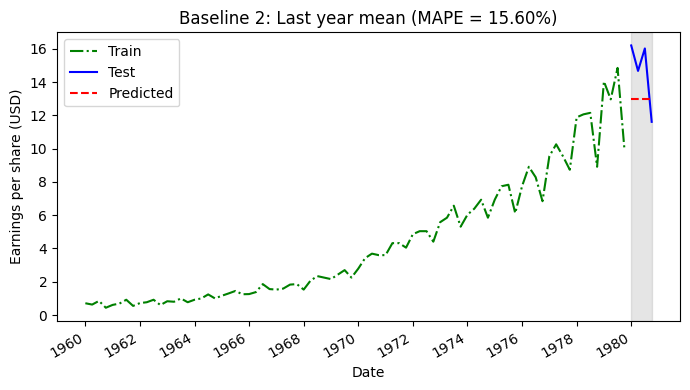

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(train['date'], train['data'], 'g-.', label='Train')
ax.plot(test['date'], test['data'], 'b-', label='Test')
ax.plot(test['date'], test['pred_last_yr_mean'], 'r--', label='Predicted')
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.set_title('Baseline 2: Last year mean (MAPE = 15.60%)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)
ax.legend(loc='upper left')

plt.xticks(np.arange(0, 85, 8),
           [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**Figure 2.3** shows the dramatic improvement: the red prediction line at \$12.96 sits right inside the corridor of the 1980 actuals (\$11.61 to \$16.20), where before it sat $\$8$ below. The flat prediction is still off in detail -- it cannot follow the within-year wiggle -- but it is no longer off by an order of magnitude.

**What we have just learned (informally).** Future values in this series depend more on *nearby* past values than on *distant* past values. This is the qualitative shape of **autocorrelation**, a concept we will formalize in chapters 4 and 5. Autocorrelation -- the correlation of a series with a lagged version of itself -- is the backbone of the autoregressive (AR) family of models.

**Could we improve further by going even more recent?**


## 2.5 Baseline 3: The last known value

**The model.** Take the most recent training observation -- the EPS for 1979-Q4 -- and use it as the prediction for every quarter of 1980.

$$\hat y_t = y_{n_{\text{train}}} \quad \text{for all } t \text{ in test}$$

This is the most extreme recency-weighted forecast: only the *single* most recent point matters. It is also the simplest forecasting model in existence: it is the **naive forecast**, sometimes called the **random-walk forecast** because it is optimal when the series follows a pure random walk (a concept developed in chapter 3 of the book).


In [11]:
last = train['data'].iloc[-1]
print(f"Last training observation (1979-Q4): ${last:.4f}")


Last training observation (1979-Q4): $9.9900


The last training observation is **\$9.99** -- the Q4-1979 value. Note that this is *substantially smaller* than the 1979 mean of \$12.96, because Q4 is the year's seasonal trough in this series (the strong Q4 dip we identified in chapter 1).

This already tells us the prediction will be problematic: we are about to forecast a year that includes Q1, Q2, Q3 (all seasonally above-trend) using a value that is itself seasonally below-trend. Let's see the damage.


In [12]:
test.loc[:, 'pred_last'] = last

mape_last = mape(test['data'].values, test['pred_last'].values)
print(f"MAPE of last-known-value baseline: {mape_last:.2f}%")
print(f"\nCompared to last-year-mean baseline ({mape_last_year_mean:.2f}%):")
print(f"  Change: {mape_last - mape_last_year_mean:+.2f} percentage points  (worse)")


MAPE of last-known-value baseline: 30.46%

Compared to last-year-mean baseline (15.60%):
  Change: +14.86 percentage points  (worse)


The MAPE jumps from $15.60\%$ to **$30.46\%$** -- nearly twice as bad. Our hypothesis that "more recent = better" has broken: pushing further toward the present *hurt* us this time.

The reason is exactly the one we anticipated. Using $9.99$ as the constant forecast undershoots every 1980 quarter by a wide margin:

- Q1: predicted \$9.99, actual \$16.20 -- off by $38.3\%$.
- Q2: predicted \$9.99, actual \$14.67 -- off by $31.9\%$.
- Q3: predicted \$9.99, actual \$16.02 -- off by $37.6\%$.
- Q4: predicted \$9.99, actual \$11.61 -- off by $13.9\%$ (least bad, because Q4 is the seasonal trough in 1980 too).

Averaging gives $30.46\%$.

**The structural problem.** The single most recent point is *not representative of the next four points* when there is a strong seasonal cycle. Q4 is at the bottom of the cycle; the next four quarters will not stay at that level -- Q1, Q2, Q3 of the new year will climb back to the seasonal peak. A baseline that fails to acknowledge this throws away all the structure we have available.


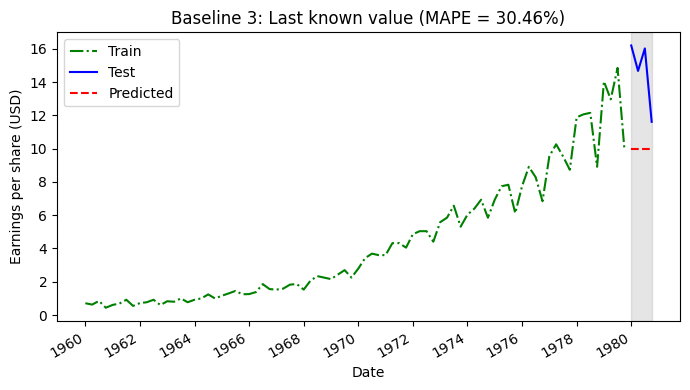

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(train['date'], train['data'], 'g-.', label='Train')
ax.plot(test['date'], test['data'], 'b-', label='Test')
ax.plot(test['date'], test['pred_last'], 'r--', label='Predicted')
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.set_title('Baseline 3: Last known value (MAPE = 30.46%)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)
ax.legend(loc='upper left')

plt.xticks(np.arange(0, 85, 8),
           [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**Figure 2.4** shows the prediction line at \$9.99, clearly below the entire 1980 test band. The gap is about half of what it was in figure 2.2 (historical mean), but worse than figure 2.3 (last-year mean).

**Lesson learned.** Recency alone is not enough when the series has seasonality. We need a baseline that recognizes the **periodic structure**: that what is "the same" about 1979-Q1 and 1980-Q1 is more useful than what is "the same" about 1979-Q4 and 1980-Q1.

That observation leads directly to the final baseline.


## 2.6 Baseline 4: The naive seasonal forecast

**The model.** Repeat the last full seasonal cycle. For a quarterly series with annual seasonality (period $= 4$), the prediction for 1980-Q$k$ is simply the value observed for 1979-Q$k$.

$$\hat y_{t} = y_{t - m}$$

where $m = 4$ is the seasonal period. So:

- $\hat y_{1980-\text{Q}1} = y_{1979-\text{Q}1} = 14.04$
- $\hat y_{1980-\text{Q}2} = y_{1979-\text{Q}2} = 12.96$
- $\hat y_{1980-\text{Q}3} = y_{1979-\text{Q}3} = 14.85$
- $\hat y_{1980-\text{Q}4} = y_{1979-\text{Q}4} = 9.99$

Unlike the previous three baselines, this one is **not constant** -- each future quarter gets its own prediction, drawn from the same quarter one year earlier. This is the simplest forecast that respects the seasonal structure of the data.


In [14]:
test.loc[:, 'pred_last_season'] = train['data'][-4:].values
print(test.to_string(index=True))

mape_naive_seasonal = mape(test['data'].values, test['pred_last_season'].values)
print(f"\nMAPE of naive seasonal forecast: {mape_naive_seasonal:.2f}%")
print(f"\nCompared to last-year-mean ({mape_last_year_mean:.2f}%):")
print(f"  Change: {mape_naive_seasonal - mape_last_year_mean:+.2f} percentage points")


          date   data  pred_mean  pred_last_yr_mean  pred_last  pred_last_season
80  1980-01-01  16.20     4.3085              12.96       9.99             14.04
81  1980-04-01  14.67     4.3085              12.96       9.99             12.96
82  1980-07-02  16.02     4.3085              12.96       9.99             14.85
83  1980-10-01  11.61     4.3085              12.96       9.99              9.99

MAPE of naive seasonal forecast: 11.56%

Compared to last-year-mean (15.60%):
  Change: -4.03 percentage points


The test DataFrame now shows all four baselines side by side. For the naive seasonal forecast specifically, each row matches the same quarter from 1979:

| | Actual 1980 | Predicted (Q from 1979) | Per-quarter error |
|---|---|---|---|
| Q1 | \$16.20 | \$14.04 | $13.33\%$ |
| Q2 | \$14.67 | \$12.96 | $11.66\%$ |
| Q3 | \$16.02 | \$14.85 | $7.30\%$ |
| Q4 | \$11.61 | \$9.99  | $13.95\%$ |

Averaging the four per-quarter percentages: $(13.33 + 11.66 + 7.30 + 13.95)/4 = 11.56\%$ -- matching the reported MAPE of **$11.56\%$**. This is the best of all four baselines, beating the previous best (last-year mean at $15.60\%$) by $4.0$ percentage points and the worst (historical mean at $70.01\%$) by $58.4$ percentage points.

The residual error in each quarter has a consistent sign: 1980 values are *higher* than the corresponding 1979 values. That is the trend asserting itself again -- the seasonal pattern is the right *shape*, but it is shifted upward by one year of growth. A more sophisticated model (SARIMA in chapter 8) will combine both signals: the seasonal pattern *and* the trend's drift on top of it.

Now plot the result:


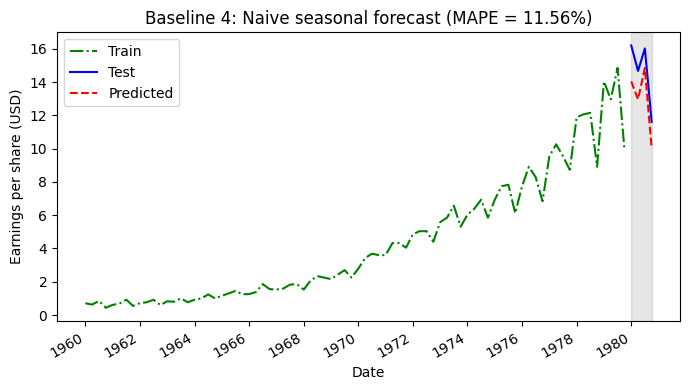

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(train['date'], train['data'], 'g-.', label='Train')
ax.plot(test['date'], test['data'], 'b-', label='Test')
ax.plot(test['date'], test['pred_last_season'], 'r--', label='Predicted')
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.set_title('Baseline 4: Naive seasonal forecast (MAPE = 11.56%)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)
ax.legend(loc='upper left')

plt.xticks(np.arange(0, 85, 8),
           [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**Figure 2.5** is the clearest visual yet. The red prediction line is no longer flat -- it traces the same up-up-up-down shape as the blue test line, just one notch lower. The gap is small, the *shape* is right, and the per-quarter prediction is in the same neighborhood as the actual for every quarter.

**Lesson learned.** Seasonality is a large component of this series, and any baseline that ignores it leaves substantial accuracy on the table. The single line `train['data'][-4:].values` -- assigning the last four training points as predictions for the next four test points -- is enough to halve the MAPE compared to a constant-mean baseline.

This is the most important insight of the chapter. It motivates everything that comes later: SARIMA (chapter 8) explicitly models a seasonal AR/MA structure; deep-learning models (chapter 12+) include seasonality through input windows that span at least one full period; production forecasting systems always evaluate against a naive seasonal benchmark.


## 2.7 Comparing the four baselines

Let us put all four MAPE values side by side and pick our champion.


In [16]:
results = pd.DataFrame({
    'baseline': ['historical_mean', 'last_year_mean', 'last_known_value', 'naive_seasonal'],
    'description': [
        'Mean of all 1960-1979 quarters',
        'Mean of 1979 quarters only',
        'Single value from 1979-Q4',
        'Repeat 1979 values quarter-by-quarter',
    ],
    'MAPE (%)': [mape_hist_mean, mape_last_year_mean, mape_last, mape_naive_seasonal],
})
results = results.sort_values('MAPE (%)').reset_index(drop=True)
print(results.to_string(index=False))


        baseline                           description  MAPE (%)
  naive_seasonal Repeat 1979 values quarter-by-quarter 11.561659
  last_year_mean            Mean of 1979 quarters only 15.596368
last_known_value             Single value from 1979-Q4 30.457278
 historical_mean        Mean of all 1960-1979 quarters 70.007526


Sorted from best to worst:

1. **Naive seasonal** -- $11.56\%$. Repeats the last full annual cycle.
2. **Last year's mean** -- $15.60\%$. Average of the most recent four quarters.
3. **Last known value** -- $30.46\%$. The single most recent observation.
4. **Historical mean** -- $70.01\%$. Average of everything.

The ordering is informative. The two top performers both use *only* the last four observations of the training set; the bottom two either use *too much* of the past (historical mean dragged down by old values) or *too little* (last value ignores seasonality). The lesson generalizes: the right "recency window" for a baseline depends on the seasonal period and the trend rate.

A small bar chart makes the magnitudes vivid.


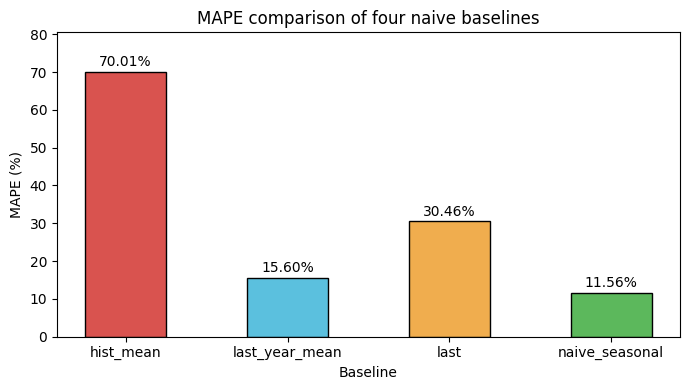

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))

labels = ['hist_mean', 'last_year_mean', 'last', 'naive_seasonal']
values = [mape_hist_mean, mape_last_year_mean, mape_last, mape_naive_seasonal]
colors = ['#d9534f', '#5bc0de', '#f0ad4e', '#5cb85c']

bars = ax.bar(labels, values, width=0.5, color=colors, edgecolor='black')
ax.set_xlabel('Baseline')
ax.set_ylabel('MAPE (%)')
ax.set_ylim(0, max(values) * 1.15)
ax.set_title('MAPE comparison of four naive baselines')

for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1.5, f'{v:.2f}%',
            ha='center', fontsize=10)

plt.tight_layout()
plt.show()


**Figure 2.6** ranks the baselines visually. The naive seasonal bar (green) at $11.56\%$ is clearly the shortest. The historical-mean bar (red) at $70.01\%$ towers over the others, illustrating just how badly a non-recency-aware constant fails on a trending series.

The naive seasonal forecast becomes our **benchmark** going forward. Every subsequent model in the book -- AR, MA, ARMA, ARIMA, SARIMA, SARIMAX, CNN, LSTM, Prophet -- must produce a test MAPE *lower than $11.56\%$* on this dataset to justify its added complexity.

In production settings this discipline is enforced rigorously: if a multi-million-parameter neural network cannot beat `train[-4:].values`, the network does not ship. A useful related quantity is the **mean absolute scaled error (MASE)**, which divides a candidate model's error by the naive seasonal baseline's error; values below $1$ mean "better than naive seasonal," values above $1$ mean "worse." We won't introduce MASE formally here, but the principle is the same -- baselines define the bar.


## 2.8 Next steps

In this chapter we:

- Defined a **baseline model** as a trivial forecast based on heuristics or simple statistics, requiring no fitting and serving as the minimum bar that complex models must beat.
- Built and scored four naive baselines on J&J quarterly EPS:
  the historical mean ($70.01\%$ MAPE), last year's mean ($15.60\%$), the last known value ($30.46\%$), and the naive seasonal forecast ($11.56\%$).
- Introduced **MAPE** as a scale-independent, interpretable error metric for forecasting.
- Learned three structural facts about the data, without any modeling, just from the *ranking* of baseline errors:
  1. The series has a strong **trend** (the historical mean is far below the recent values).
  2. **Recent values are more predictive than distant ones** (a hint at autocorrelation, formalized in chapter 5).
  3. The series has strong **annual seasonality** (the naive seasonal forecast halves the MAPE of the next-best baseline).

**What comes next.** Chapter 3 introduces the **random walk** -- a special class of time series for which *no model can beat the naive last-value forecast*, because the next value is genuinely unpredictable from the past. We will learn to identify random walks via the **augmented Dickey-Fuller test** and the **autocorrelation function**, both of which become essential diagnostic tools for everything that follows. From chapter 4 onward we then build proper statistical models -- the moving average (MA), the autoregressive (AR), and their generalizations (ARMA, ARIMA, SARIMA) -- and we measure each one against the $11.56\%$ benchmark established here.

### Summary

- Time series forecasting starts with a **baseline model** that serves as a benchmark for comparison with more complex models.
- A baseline model is a trivial solution that uses heuristics or simple statistics -- no fitting required.
- **MAPE** (mean absolute percentage error) is a scale-independent, interpretable metric: $\text{MAPE} = (100/n)\sum |A_i - F_i|/|A_i|$.
- Four common naive baselines are the historical mean, the last year's mean, the last known value, and the naive seasonal forecast. On the J&J data the naive seasonal forecast wins with MAPE $= 11.56\%$.
- The **ranking** of baseline errors gives us early structural information about the data: it tells us a trend exists, that recency matters, and that seasonality is significant -- all before we run a single statistical test.
